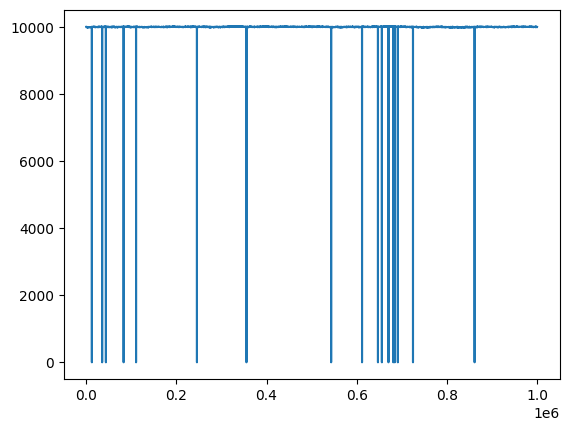

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import statistics

prices_df = pd.read_csv("../datasets/round1/prices_round_1_day_-1.csv", sep=';')

pepper_prices_df = prices_df[prices_df["product"] == "INTARIAN_PEPPER_ROOT" ]
osmium_prices_df = prices_df[prices_df["product"] == "ASH_COATED_OSMIUM" ]
# tomatoes_df = df[["timestamp", "mid_price"]]
pepper_prices_df

#tomatopricesvolumeover5 = tomatoes_prices_df[tomatoes_prices_df[""] >= 5]

#plt.plot(pepper_prices_df['timestamp'], pepper_prices_df['mid_price'])
plt.plot(osmium_prices_df['timestamp'], osmium_prices_df['mid_price'])

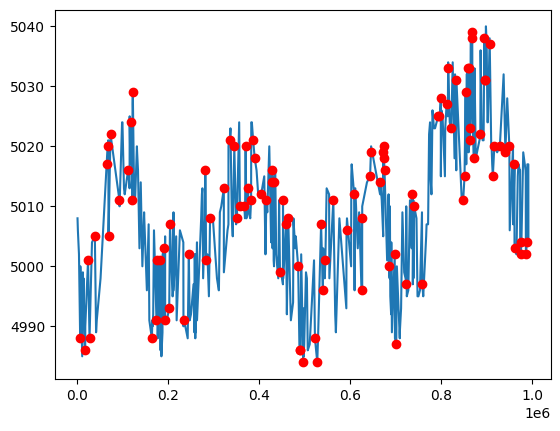

In [ ]:
# Load round1 trades (day -2 and day -1)
day_02_trades_df = pd.read_csv("../datasets/round1/trades_round_1_day_-2.csv", sep=';')
day_01_trades_df = pd.read_csv("../datasets/round1/trades_round_1_day_-1.csv", sep=';')

# Filter trades for round1 products used in the notebook
day_02_pepper_trades = day_02_trades_df[day_02_trades_df["symbol"] == "INTARIAN_PEPPER_ROOT"].sort_values('timestamp')
day_01_pepper_trades = day_01_trades_df[day_01_trades_df["symbol"] == "INTARIAN_PEPPER_ROOT"].sort_values('timestamp')

day_02_osmium_trades = day_02_trades_df[day_02_trades_df["symbol"] == "ASH_COATED_OSMIUM"].sort_values('timestamp')
day_01_osmium_trades = day_01_trades_df[day_01_trades_df["symbol"] == "ASH_COATED_OSMIUM"].sort_values('timestamp')

# Keep TOMATOES too for the existing plots/analysis
day_02_tomatoes_trades_df = day_02_trades_df[day_02_trades_df["symbol"] == "TOMATOES"].sort_values('timestamp')
day_01_tomatoes_trades_df = day_01_trades_df[day_01_trades_df["symbol"] == "TOMATOES"].sort_values('timestamp')

print('Counts: day-2 pepper', len(day_02_pepper_trades), 'osmium', len(day_02_osmium_trades), 'tomatoes', len(day_02_tomatoes_trades_df))
print('Counts: day-1 pepper', len(day_01_pepper_trades), 'osmium', len(day_01_osmium_trades), 'tomatoes', len(day_01_tomatoes_trades_df))

quantity5trades = day_02_tomatoes_trades_df[day_02_tomatoes_trades_df["quantity"] >= 5]

plt.plot(day_02_tomatoes_trades_df['timestamp'], day_02_tomatoes_trades_df['price'])
#plt.plot(day_02_tomatoes_trades_df['timestamp'], day_02_tomatoes_trades_df['quantity'])

plt.plot(quantity5trades['timestamp'], quantity5trades['price'], 'ro')

n=10000 slope=1.008554e+00 intercept=10976.253212 r2=0.275548 p=0.0 std_err=0.0163549327764304


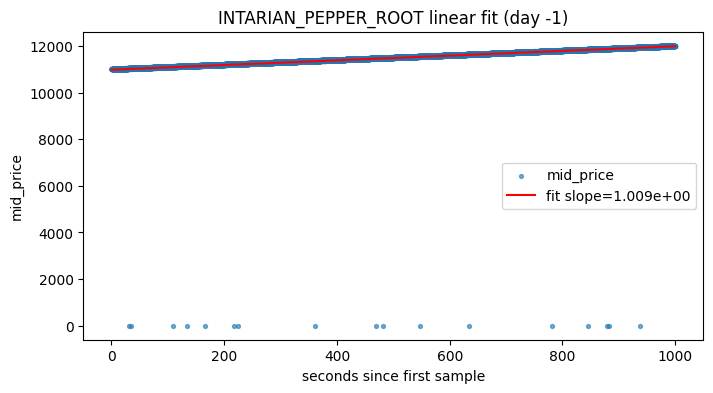

In [ ]:
# Linear regression of INTARIAN_PEPPER_ROOT mid_price vs timestamp (day -1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

path = '../datasets/round1/prices_round_1_day_-1.csv'
df = pd.read_csv(path, sep=';')
pep = df[df['product'] == 'INTARIAN_PEPPER_ROOT'].sort_values('timestamp')
ts = pep['timestamp'].astype(float).to_numpy()
prices = pep['mid_price'].astype(float).to_numpy()
# use raw timestamp as x-axis (no conversion to seconds)
slope, intercept, r_value, p_value, std_err = stats.linregress(ts, prices)
print(f'n={len(prices)} slope={slope:.6e} intercept={intercept:.6f} r2={r_value**2:.6f} p={p_value} std_err={std_err}')
plt.figure(figsize=(8,4))
plt.scatter(ts, prices, s=8, alpha=0.6, label='mid_price')
xs = np.linspace(ts.min(), ts.max(), 200)
ys = intercept + slope * xs
plt.plot(xs, ys, 'r-', label=f'fit slope={slope:.3e}')
plt.xlabel('timestamp')
plt.ylabel('mid_price')
plt.title('INTARIAN_PEPPER_ROOT linear fit (day -1)')
plt.legend()
plt.show()

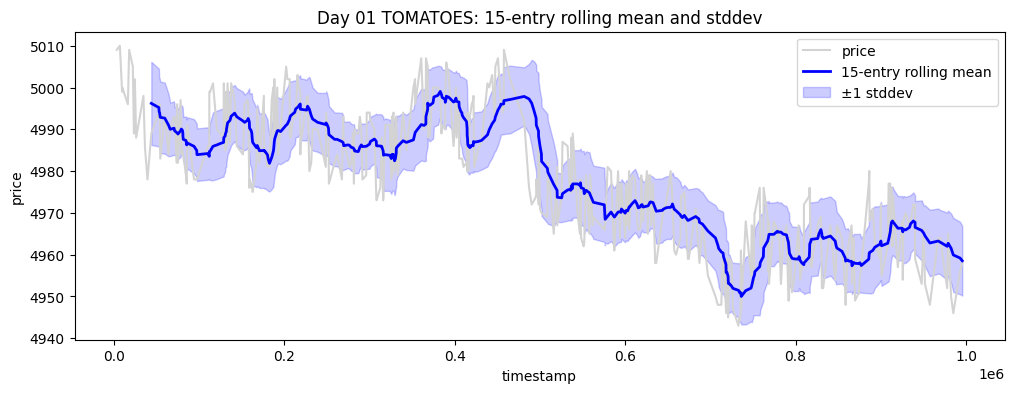

In [6]:
# 15-entry rolling mean and stddev for day 01 TOMATOES trades
df = day_01_tomatoes_trades_df.sort_values('timestamp')
roll = df['price'].rolling(window=15, min_periods=15)
rolling_mean = roll.mean()
rolling_std = roll.std()

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['price'], color='lightgray', label='price')
plt.plot(df['timestamp'], rolling_mean, color='blue', linewidth=2, label='15-entry rolling mean')
plt.fill_between(df['timestamp'], rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.2, label='±1 stddev')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.title('Day 01 TOMATOES: 15-entry rolling mean and stddev')
plt.show()

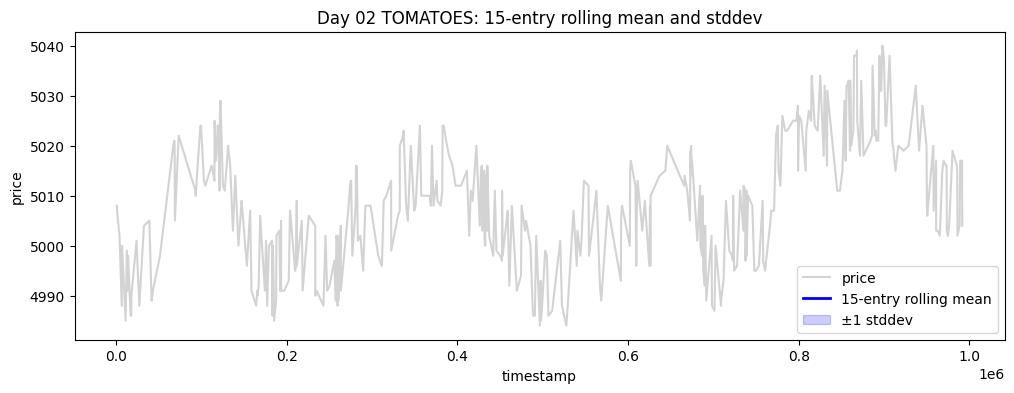

In [11]:
# 15-entry rolling mean and stddev for day 02 TOMATOES trades
df = day_02_tomatoes_trades_df.sort_values('timestamp')
roll = df['price'].rolling(window=500, min_periods=500)
rolling_mean = roll.mean()
rolling_std = roll.std()

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['price'], color='lightgray', label='price')
plt.plot(df['timestamp'], rolling_mean, color='blue', linewidth=2, label='15-entry rolling mean')
plt.fill_between(df['timestamp'], rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.2, label='±1 stddev')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.title('Day 02 TOMATOES: 15-entry rolling mean and stddev')
plt.show()

In [ ]:
# 15-entry rolling mean and stddev for day 01 ASH_COATED_OSMIUM trades
df = day_01_osmium_trades.sort_values('timestamp')
roll = df['price'].rolling(window=15, min_periods=15)
rolling_mean = roll.mean()
rolling_std = roll.std()

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['price'], color='lightgray', label='price')
plt.plot(df['timestamp'], rolling_mean, color='blue', linewidth=2, label='15-entry rolling mean')
plt.fill_between(df['timestamp'], rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.2, label='±1 stddev')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.title('Day 01 ASH_COATED_OSMIUM: 15-entry rolling mean and stddev')
plt.show()

In [ ]:
# 50-entry rolling mean and stddev for day 02 ASH_COATED_OSMIUM trades
df = day_02_osmium_trades.sort_values('timestamp')
roll = df['price'].rolling(window=50, min_periods=50)
rolling_mean = roll.mean()
rolling_std = roll.std()

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['price'], color='lightgray', label='price')
plt.plot(df['timestamp'], rolling_mean, color='blue', linewidth=2, label='50-entry rolling mean')
plt.fill_between(df['timestamp'], rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.2, label='±1 stddev')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.title('Day 02 ASH_COATED_OSMIUM: 50-entry rolling mean and stddev')
plt.show()

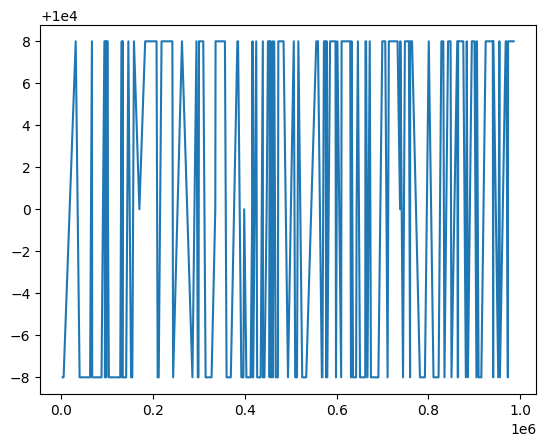

In [8]:
day_01_emerald_trades_df = day_01_trades_df[day_01_trades_df["symbol"] == "EMERALDS" ]



plt.plot(day_01_emerald_trades_df['timestamp'], day_01_emerald_trades_df['price'])


Hurst: day -1: 0.1521, day -2: 0.1518, combined: 0.2317


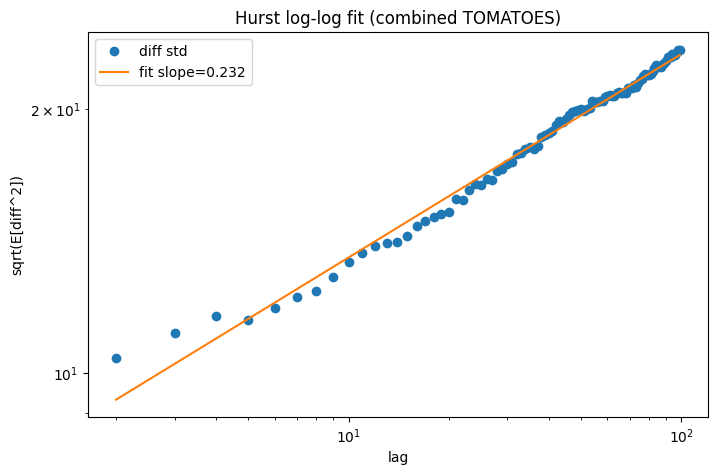

In [9]:
# Hurst exponent test and log-log plot for TOMATOES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def hurst_exponent(prices, maxlag=None):
    ts = np.asarray(prices, dtype=float)
    N = len(ts)
    if N < 10:
        return np.nan, None, None
    if maxlag is None:
        maxlag = min(100, max(10, N // 2))
    lags = np.arange(2, maxlag)
    tau = []
    for lag in lags:
        diff = ts[lag:] - ts[:-lag]
        tau.append(np.sqrt(np.mean(diff**2)))
    # linear fit on log-log
    slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(lags), np.log(tau))
    H = slope
    return float(H), (lags, tau), (slope, intercept)

# load trades (they are already loaded in previous cells; but re-read to be safe)
d1 = pd.read_csv('../datasets/tutorial/trades_round_0_day_-1.csv', sep=';')
d2 = pd.read_csv('../datasets/tutorial/trades_round_0_day_-2.csv', sep=';')
t1 = d1[d1['symbol'] == 'TOMATOES'].sort_values('timestamp')
t2 = d2[d2['symbol'] == 'TOMATOES'].sort_values('timestamp')
p1 = t1['price'].to_numpy()
p2 = t2['price'].to_numpy()
combined = np.concatenate([p1, p2]) if (len(p1) and len(p2)) else (p1 if len(p1) else p2)

# compute Hurst for day -1, day -2, and combined
H1, data1, fit1 = hurst_exponent(p1)
H2, data2, fit2 = hurst_exponent(p2)
Hc, datac, fitc = hurst_exponent(combined)
print('Hurst: day -1: {:.4f}, day -2: {:.4f}, combined: {:.4f}'.format(H1, H2, Hc))

# plot log-log with linear fit for combined (if available)
if datac is not None:
    lags, tau = datac
    slope, intercept = fitc
    plt.figure(figsize=(8,5))
    plt.loglog(lags, tau, 'o', label='diff std')
    plt.loglog(lags, np.exp(intercept) * lags**slope, '-', label=f'fit slope={slope:.3f}')
    plt.xlabel('lag')
    plt.ylabel('sqrt(E[diff^2])')
    plt.title('Hurst log-log fit (combined TOMATOES)')
    plt.legend()
    plt.show()

# save price series and Hurst results to CSV
out_df = pd.DataFrame({'price': combined})
out_df.to_csv('tomato_prices_combined.csv', index=False)
with open('tomato_hurst_results.txt', 'w') as f:
    f.write(f"day -1: n={len(p1)} H={H1}\n")
    f.write(f"day -2: n={len(p2)} H={H2}\n")
    f.write(f"combined: n={len(combined)} H={Hc}\n")

In [ ]:
# Combine all three round 1 days for ASH_COATED_OSMIUM and compute the average mid_price
day_02_prices_df = pd.read_csv("../datasets/round1/prices_round_1_day_-2.csv", sep=";")
day_01_prices_df = pd.read_csv("../datasets/round1/prices_round_1_day_-1.csv", sep=";")
day_0_prices_df = pd.read_csv("../datasets/round1/prices_round_1_day_0.csv", sep=";")

all_days_osmium_prices = pd.concat([day_02_prices_df, day_01_prices_df, day_0_prices_df], ignore_index=True)
all_days_osmium_prices = all_days_osmium_prices[all_days_osmium_prices["product"] == "ASH_COATED_OSMIUM"]

daily_osmium_averages = all_days_osmium_prices.groupby("day")["mid_price"].mean()
total_osmium_average = all_days_osmium_prices["mid_price"].mean()

print(daily_osmium_averages)
print(f"Total average ASH_COATED_OSMIUM mid_price: {total_osmium_average:.6f}")
